In [1]:
# Cellule 1 — d'abord une stack compilée cohérente (wheels PyPI, même ABI numpy 1.x)
!pip install -q --force-reinstall --no-cache-dir numpy==1.26.4 pandas==2.2.2 tables

# puis les packages purement Python, build isolation NORMALE (pas de --no-build-isolation)
!pip install -q networkx
!pip install -q git+https://github.com/nilmtk/nilm_metadata.git
!pip install -q git+https://github.com/nilmtk/nilmtk.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 159.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 188.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 189.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 188.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 187.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.6/443.6 kB 167.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 172.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 173.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 183.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 169.8 MB/s eta 0:00:00
   ━━━

In [2]:
from nilmtk import DataSet
from collections import Counter
print("NILMTK installed and imported successfully")
print("collections imported successfully")

NILMTK installed and imported successfully
collections imported successfully


In [3]:
# ===== CELLULE 0 : imports =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter
from nilmtk import DataSet

SAMPLE_PERIOD = 6  # secondes

In [49]:
# ===== CELLULE 1 : chargement + maison 1 =====
ukdale = DataSet('/kaggle/input/datasets/abdelmdz/uk-dale/ukdale.h5')
elec = ukdale.buildings[5].elec

In [50]:
# ===== CELLULE 2 : inventaire des types d'appareils =====
# On passe par app.identifier au lieu de découper label() à la main :
# identifier est un namedtuple ApplianceID(type, instance), plus robuste.
appliance_names = [app.identifier.type for app in elec.appliances]
counts = Counter(appliance_names)

print(counts)
print("Total appareils      :", len(appliance_names))
print("Types distincts      :", len(counts))

Counter({'computer monitor': 2, 'desktop computer': 2, 'microwave': 1, 'washer dryer': 1, 'hair dryer': 1, 'active speaker': 1, 'server computer': 1, 'audio amplifier': 1, 'set top box': 1, 'kettle': 1, 'fridge freezer': 1, 'vacuum cleaner': 1, 'dish washer': 1, 'coffee maker': 1, 'clothes iron': 1, 'electric stove': 1, 'games console': 1, 'toaster': 1, 'running machine': 1, 'network attached storage': 1, 'electric oven': 1, 'television': 1})
Total appareils      : 24
Types distincts      : 22


In [51]:
# ===== CELLULE 3 : mains =====
mains = elec.mains()
df_mains = next(mains.load())
print(df_mains.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11405812 entries, 2014-06-29 17:23:43.200000+01:00 to 2014-11-13 20:35:25.100000+00:00
Data columns (total 3 columns):
 #   Column             Dtype  
---  ------             -----  
 0   (power, active)    float32
 1   (power, apparent)  float32
 2   (voltage, )        float32
dtypes: float32(3)
memory usage: 217.5 MB
None


In [52]:
# ===== CELLULE 4 : inventaire des submeters (nb d'appareils + dates_active) =====
for i, meter in enumerate(elec.submeters().meters):
    apps = meter.appliances
    print('#'*30, f'meter index {i} (instance {meter.instance()})', '#'*30)
    print(f"  nb appareils sur ce meter : {len(apps)}")
    for app in apps:
        print("   ->", app.identifier,
              "| dates_active:", app.metadata.get('dates_active', 'n/a'))

############################## meter index 0 (instance 2) ##############################
  nb appareils sur ce meter : 1
   -> ApplianceID(type='active speaker', instance=1) | dates_active: n/a
############################## meter index 1 (instance 3) ##############################
  nb appareils sur ce meter : 1
   -> ApplianceID(type='desktop computer', instance=1) | dates_active: n/a
############################## meter index 2 (instance 4) ##############################
  nb appareils sur ce meter : 1
   -> ApplianceID(type='hair dryer', instance=1) | dates_active: n/a
############################## meter index 3 (instance 5) ##############################
  nb appareils sur ce meter : 1
   -> ApplianceID(type='television', instance=1) | dates_active: n/a
############################## meter index 4 (instance 6) ##############################
  nb appareils sur ce meter : 1
   -> ApplianceID(type='computer monitor', instance=1) | dates_active: n/a
############################## met

In [53]:
# ===== CELLULE 5 : fonctions utilitaires =====

def load_meter_power(meter, sample_period=SAMPLE_PERIOD):
    """Charge la série de puissance d'un meter.
    Choisit 'active' si dispo, sinon 'apparent'. Renvoie (series, ac_type)."""
    acs = meter.available_ac_types('power')
    if not acs:
        return None, None
    ac = 'active' if 'active' in acs else 'apparent'
    chunks = list(meter.load(ac_type=ac, sample_period=sample_period))
    if not chunks:
        return None, ac
    df = pd.concat(chunks)
    col = ('power', ac)
    s = df[col] if col in df.columns else df.iloc[:, 0]
    s = s.astype('float32')          # mémoire : ~23M pts par série
    s.name = f"{meter.instance()}_{ac}"
    return s, ac


def parse_dates_active(app):
    """Renvoie [(start, end), ...] en Timestamps (ou None aux bornes ouvertes),
    ou None si dates_active est absent / vide."""
    da = app.metadata.get('dates_active', None)
    if not da:                       # None ou []
        return None
    windows = []
    for d in da:
        start = pd.Timestamp(d['start']) if d.get('start') else None
        end   = pd.Timestamp(d['end'])   if d.get('end')   else None
        windows.append((start, end))
    return windows or None


def mask_outside_windows(series, windows):
    """Met NaN partout en dehors des fenêtres dates_active.
    Gère l'index tz-aware (Europe/London) d'UK-DALE."""
    if not windows:
        return series.astype('float32')
    idx = series.index
    tz = idx.tz
    keep = np.zeros(len(idx), dtype=bool)
    for start, end in windows:
        lo = idx[0]  if start is None else pd.Timestamp(start)
        hi = idx[-1] if end   is None else pd.Timestamp(end)
        if tz is not None:
            if lo.tzinfo is None:
                lo = lo.tz_localize(tz, ambiguous='NaT', nonexistent='shift_forward')
            if hi.tzinfo is None:
                hi = hi.tz_localize(tz, ambiguous='NaT', nonexistent='shift_forward')
        keep |= (idx >= lo) & (idx <= hi)
    out = series.astype('float32').copy()
    out[~keep] = np.nan
    return out


def any_overlap(win_a, win_b):
    """True si deux jeux de fenêtres se chevauchent.
    None = borne ouverte (-inf pour start, +inf pour end).
    On ne compare que des timestamps réels entre eux -> pas de souci tz."""
    def overlaps(s1, e1, s2, e2):
        # [s1,e1] et [s2,e2] disjoints ssi  e1 <= s2  ou  e2 <= s1
        # (<= : deux fenetres qui se TOUCHENT, cas remplacement A->B, ne comptent pas)
        if e1 is not None and s2 is not None and e1 <= s2:
            return False
        if e2 is not None and s1 is not None and e2 <= s1:
            return False
        return True
    for (s1, e1) in win_a:
        for (s2, e2) in win_b:
            if overlaps(s1, e1, s2, e2):
                return True
    return False

In [54]:
# ===== CELLULE 6 : extraction de tous les submeters =====
# Logique :
#  - meter à 1 appareil  -> série brute attribuée à l'appareil
#  - meter à N appareils -> si TOUS ont dates_active : on masque (NaN) hors fenêtre
#                          -> sinon : non séparable -> regroupé dans "autres"
# Séparation active / apparente respectée (homogénéité à l'entraînement).
# Construit aussi : seuils_meta, seuils_origine, obj_par_key (pour la saisie 6.5).

SEUIL_DEFAUT = 10.0   # W (repli quand aucune info dans le metadata)

def get_on_threshold_from_app(app, defaut=SEUIL_DEFAUT):
    """Renvoie (seuil, origine) par ordre de priorité :
       1) on_power_threshold (explicite)
       2) 50% de nominal_consumption.on_power
       3) 50% de distributions.on_power.model.mu
       4) défaut."""
    m = app.metadata
    thr = m.get('on_power_threshold')
    if thr is not None:
        return float(thr), 'on_power_threshold'
    nom = m.get('nominal_consumption', {})
    if isinstance(nom, dict) and nom.get('on_power') is not None:
        return 0.5 * float(nom['on_power']), 'nominal/2'
    on_dist = m.get('distributions', {}).get('on_power')
    if on_dist:
        mu = on_dist[0].get('model', {}).get('mu')
        if mu is not None:
            return 0.5 * float(mu), 'mu/2'
    return defaut, 'defaut'

def get_on_threshold_meter(meter, defaut=SEUIL_DEFAUT):
    """Meter multi-appareils non séparable : seuil le plus sensible (min)."""
    pairs = [get_on_threshold_from_app(a, defaut) for a in meter.appliances]
    if not pairs:
        return defaut, 'defaut'
    return min(pairs, key=lambda p: p[0])   # (val, origine)


D_active   = {}   # appareils mesurés en puissance ACTIVE
D_apparent = {}   # appareils mesurés en puissance APPARENTE
autres     = {}   # meters non séparables
ac_used    = {}
seuils_meta    = {}   # key -> seuil ON (W)
seuils_origine = {}   # key -> origine du seuil
obj_par_key    = {}   # key -> ('app', app) ou ('meter', meter)

for meter in elec.submeters().meters:
    apps = meter.appliances
    s, ac = load_meter_power(meter)
    if s is None:
        print(f"meter {meter.instance()} : pas de 'power' -> skip")
        continue
    target = D_active if ac == 'active' else D_apparent

    # --- 1 seul appareil ---
    if len(apps) == 1:
        key = apps[0].identifier
        target[key] = s
        ac_used[key] = ac
        seuils_meta[key], seuils_origine[key] = get_on_threshold_from_app(apps[0])
        obj_par_key[key] = ('app', apps[0])
        continue

    # --- plusieurs appareils ---
    win = {app.identifier: parse_dates_active(app) for app in apps}
    separable = all(w is not None for w in win.values())

    if separable:
        # diagnostic chevauchement : fenêtres qui se recouvrent
        # -> même puissance attribuée à 2 appareils -> séparation illusoire
        ids = list(win.keys())
        for a in range(len(ids)):
            for b in range(a + 1, len(ids)):
                if any_overlap(win[ids[a]], win[ids[b]]):
                    print(f"  ATTENTION chevauchement : {ids[a]} & {ids[b]} "
                          f"(meter {meter.instance()}) -> séparation non fiable")
        for app in apps:
            key = app.identifier
            target[key] = mask_outside_windows(s, win[key])
            ac_used[key] = ac
            seuils_meta[key], seuils_origine[key] = get_on_threshold_from_app(app)
            obj_par_key[key] = ('app', app)
    else:
        label = f"autres_meter_{meter.instance()}"
        autres[label] = s
        ac_used[label] = ac
        seuils_meta[label], seuils_origine[label] = get_on_threshold_meter(meter)
        obj_par_key[label] = ('meter', meter)
        print(f"meter {meter.instance()} : {len(apps)} appareils sans dates_active "
              f"complets -> regroupés dans '{label}'")

print("\nActive  :", len(D_active))
print("Apparent:", len(D_apparent))
print("Autres  :", len(autres))
print(Counter(ac_used.values()))


Active  : 24
Apparent: 0
Autres  : 0
Counter({'active': 24})


**A faire lorsque tu veux entrer les seuils manuellement et une fois entre copier coller**

In [55]:
# ===== CELLULE 6.5 : saisie des seuils au défaut =====
# Mets SAISIE_INTERACTIVE = True pour saisir à la main (exécution manuelle).
# Mets False avant un "Run All"/commit pour sauter la saisie sans bloquer.
import pprint

SAISIE_INTERACTIVE = True   # <<< passe à False avant le Run All final

def key_to_name(key):
    return key if isinstance(key, str) else f"{key.type} {key.instance}"

defauts = [k for k, orig in seuils_origine.items() if orig == 'defaut']
print(f"{len(defauts)} appareils au seuil par défaut ({SEUIL_DEFAUT:g} W).")

if not SAISIE_INTERACTIVE:
    print("SAISIE_INTERACTIVE=False -> saisie ignorée, seuils metadata/défaut conservés.")
else:
    print("Entrée vide = garder la valeur actuelle. Tape 'q' pour arrêter.\n")
    for n, key in enumerate(defauts, 1):
        kind, obj = obj_par_key[key]
        print("="*90)
        print(f"[{n}/{len(defauts)}]  {key_to_name(key)}   "
              f"(seuil actuel {seuils_meta[key]:g} W)")
        print("-"*90)
        if kind == 'app':
            pprint.pprint(obj.metadata, width=110, sort_dicts=False)
        else:
            for a in obj.appliances:
                print(f"  --- {a.identifier} ---")
                pprint.pprint(a.metadata, width=110, sort_dicts=False)
        print("-"*90)
        rep = input(f"Seuil pour '{key_to_name(key)}' (W) [{seuils_meta[key]:g}] : ").strip()
        if rep.lower() == 'q':
            print("Arrêt.")
            break
        if rep == '':
            print(f"  -> gardé à {seuils_meta[key]:g} W\n")
            continue
        try:
            seuils_meta[key]    = float(rep.replace(',', '.'))
            seuils_origine[key] = 'manuel'
            print(f"  -> {seuils_meta[key]:g} W\n")
        except ValueError:
            print(f"  !! '{rep}' invalide -> gardé à {seuils_meta[key]:g} W\n")

# récap final
print("\n" + "="*40 + " SEUILS FINAUX " + "="*40)
for key in sorted(seuils_meta, key=key_to_name):
    print(f"  {seuils_meta[key]:8.1f} W  [{seuils_origine[key]:>16}]  {key_to_name(key)}")

19 appareils au seuil par défaut (10 W).
Entrée vide = garder la valeur actuelle. Tape 'q' pour arrêter.

[1/19]  active speaker 1   (seuil actuel 10 W)
------------------------------------------------------------------------------------------
{'instance': 1,
 'meters': [2],
 'original_name': 'stereo_speakers_bedroom',
 'type': 'active speaker',
 'dataset': 'UK-DALE',
 'building': 5}
------------------------------------------------------------------------------------------


Seuil pour 'active speaker 1' (W) [10] :  10


  -> 10 W

[2/19]  desktop computer 1   (seuil actuel 10 W)
------------------------------------------------------------------------------------------
{'instance': 1,
 'meters': [3],
 'original_name': 'i7_desktop',
 'cpu': 'Intel i7',
 'type': 'desktop computer',
 'dataset': 'UK-DALE',
 'building': 5}
------------------------------------------------------------------------------------------


Seuil pour 'desktop computer 1' (W) [10] :  20


  -> 20 W

[3/19]  hair dryer 1   (seuil actuel 10 W)
------------------------------------------------------------------------------------------
{'instance': 1,
 'meters': [4],
 'original_name': 'hairdryer',
 'type': 'hair dryer',
 'dataset': 'UK-DALE',
 'building': 5}
------------------------------------------------------------------------------------------


...

  -> 50 W

[18/19]  electric stove 1   (seuil actuel 10 W)
------------------------------------------------------------------------------------------
{'instance': 1,
 'meters': [21],
 'original_name': 'electric_hob',
 'type': 'electric stove',
 'dataset': 'UK-DALE',
 'building': 5}
------------------------------------------------------------------------------------------


Seuil pour 'electric stove 1' (W) [10] :  50


  -> 50 W

[19/19]  vacuum cleaner 1   (seuil actuel 10 W)
------------------------------------------------------------------------------------------
{'instance': 1,
 'meters': [25],
 'original_name': 'vacuum_cleaner',
 'type': 'vacuum cleaner',
 'dataset': 'UK-DALE',
 'building': 5}
------------------------------------------------------------------------------------------


Seuil pour 'vacuum cleaner 1' (W) [10] :  40


  -> 40 W


======================================== SEUILS FINAUX ========================================
      10.0 W  [          manuel]  active speaker 1
      10.0 W  [          manuel]  audio amplifier 1
     100.0 W  [          manuel]  clothes iron 1
      40.0 W  [          manuel]  coffee maker 1
      20.0 W  [          manuel]  computer monitor 1
      20.0 W  [          manuel]  computer monitor 2
      20.0 W  [          manuel]  desktop computer 1
      20.0 W  [          manuel]  desktop computer 2
      10.0 W  [on_power_threshold]  dish washer 1
      50.0 W  [          manuel]  electric oven 1
      50.0 W  [          manuel]  electric stove 1
      50.0 W  [on_power_threshold]  fridge freezer 1
      20.0 W  [          manuel]  games console 1
      50.0 W  [          manuel]  hair dryer 1
    2000.0 W  [on_power_threshold]  kettle 1
     200.0 W  [on_power_threshold]  microwave 1
      10.0 W  [          manuel]  network attached storage 1
      50.0 W  [         

In [56]:
# génère le dict en dur à copier-coller
print("seuils_manuels = {")
for key in sorted(seuils_meta, key=lambda k: k if isinstance(k, str) else f"{k.type} {k.instance}"):
    mk = key if isinstance(key, str) else (key.type, key.instance)
    print(f"    {mk!r}: {seuils_meta[key]:g},")
print("}")

seuils_manuels = {
    ('active speaker', 1): 10,
    ('audio amplifier', 1): 10,
    ('clothes iron', 1): 100,
    ('coffee maker', 1): 40,
    ('computer monitor', 1): 20,
    ('computer monitor', 2): 20,
    ('desktop computer', 1): 20,
    ('desktop computer', 2): 20,
    ('dish washer', 1): 10,
    ('electric oven', 1): 50,
    ('electric stove', 1): 50,
    ('fridge freezer', 1): 50,
    ('games console', 1): 20,
    ('hair dryer', 1): 50,
    ('kettle', 1): 2000,
    ('microwave', 1): 200,
    ('network attached storage', 1): 10,
    ('running machine', 1): 50,
    ('server computer', 1): 10,
    ('set top box', 1): 10,
    ('television', 1): 20,
    ('toaster', 1): 100,
    ('vacuum cleaner', 1): 40,
    ('washer dryer', 1): 20,
}


**UK-DALE building 1**

In [ ]:
# ===== CELLULE 6.6 : seuils figés en dur (source de vérité unique) =====
seuils_manuels = {
    ('HTPC', 1): 20,
    ('active subwoofer', 1): 20,
    ('audio amplifier', 1): 10,
    ('audio system', 1): 10,
    'autres_meter_10': 2000,
    'autres_meter_11': 1000,
    'autres_meter_21': 20,
    'autres_meter_32': 20,
    'autres_meter_38': 1,
    'autres_meter_4': 10,
    'autres_meter_43': 20,
    ('baby monitor', 1): 10,
    ('boiler', 1): 35,
    ('bouncy castle pump', 1): 20,
    ('breadmaker', 1): 10,
    ('broadband router', 1): 10,
    ('broadband router', 2): 10,
    ('charger', 1): 10,
    ('clothes iron', 1): 50,
    ('coffee maker', 1): 50,
    ('computer monitor', 1): 10,
    ('desktop computer', 1): 20,
    ('dish washer', 1): 10,
    ('fan', 1): 20,
    ('fridge freezer', 1): 50,
    ('hair dryer', 1): 50,
    ('hair straighteners', 1): 50,
    ('light', 1): 50,
    ('light', 10): 20,
    ('light', 11): 20,
    ('light', 12): 20,
    ('light', 13): 20,
    ('light', 14): 20,
    ('light', 15): 20,
    ('light', 16): 20,
    ('light', 2): 250,
    ('light', 3): 20,
    ('light', 4): 20,
    ('light', 5): 20,
    ('light', 6): 20,
    ('light', 7): 20,
    ('light', 8): 20,
    ('light', 9): 20,
    ('microwave', 1): 200,
    ('mobile phone charger', 1): 20,
    ('oven', 1): 10,
    ('printer', 1): 30,
    ('radio', 1): 10,
    ('radio', 2): 2,
    ('solar thermal pumping station', 1): 21.5,
    ('soldering iron', 1): 50,
    ('tablet computer charger', 1): 20,
    ('television', 1): 10,
    ('vacuum cleaner', 1): 50,
    ('washer dryer', 1): 20,
    ('washer dryer', 2): 20,
}
# application : patche seuils_meta sans retoucher les DataFrames
n = 0
for key in list(seuils_meta.keys()):
    mk = key if isinstance(key, str) else (key.type, key.instance)
    if mk in seuils_manuels:
        seuils_meta[key]    = float(seuils_manuels[mk])
        seuils_origine[key] = 'manuel'
        n += 1
print(f"{n} seuils appliqués depuis seuils_manuels.")

def key_to_name(key):
    return key if isinstance(key, str) else f"{key.type} {key.instance}"
print("\nSeuils finaux (W) :")
for key in sorted(seuils_meta, key=key_to_name):
    print(f"  {seuils_meta[key]:8.1f} W  {key_to_name(key)}")

**UK-DALE building 2**

In [12]:
seuils_manuels = {
    ('active speaker', 1): 10,
    ('broadband router', 1): 10,
    ('computer', 1): 20,
    ('computer monitor', 1): 20,
    ('cooker', 1): 40,
    ('dish washer', 1): 10,
    ('external hard disk', 1): 10,
    ('fridge', 1): 50,
    ('games console', 1): 30,
    ('kettle', 1): 2000,
    ('laptop computer', 1): 20,
    ('laptop computer', 2): 20,
    ('microwave', 1): 200,
    ('modem', 1): 10,
    ('rice cooker', 1): 50,
    ('running machine', 1): 50,
    ('toaster', 1): 100,
    ('washing machine', 1): 20,
}
# application : patche seuils_meta sans retoucher les DataFrames
n = 0
for key in list(seuils_meta.keys()):
    mk = key if isinstance(key, str) else (key.type, key.instance)
    if mk in seuils_manuels:
        seuils_meta[key]    = float(seuils_manuels[mk])
        seuils_origine[key] = 'manuel'
        n += 1
print(f"{n} seuils appliqués depuis seuils_manuels.")

def key_to_name(key):
    return key if isinstance(key, str) else f"{key.type} {key.instance}"
print("\nSeuils finaux (W) :")
for key in sorted(seuils_meta, key=key_to_name):
    print(f"  {seuils_meta[key]:8.1f} W  {key_to_name(key)}")

18 seuils appliqués depuis seuils_manuels.

Seuils finaux (W) :
      10.0 W  active speaker 1
      10.0 W  broadband router 1
      20.0 W  computer 1
      20.0 W  computer monitor 1
      40.0 W  cooker 1
      10.0 W  dish washer 1
      10.0 W  external hard disk 1
      50.0 W  fridge 1
      30.0 W  games console 1
    2000.0 W  kettle 1
      20.0 W  laptop computer 1
      20.0 W  laptop computer 2
     200.0 W  microwave 1
      10.0 W  modem 1
      50.0 W  rice cooker 1
      50.0 W  running machine 1
     100.0 W  toaster 1
      20.0 W  washing machine 1


**UK-DALE BUILDING3**

In [29]:
seuils_manuels = {
    ('electric space heater', 1): 30,
    ('kettle', 1): 2000,
    ('laptop computer', 1): 20,
    ('projector', 1): 20,
}
# application : patche seuils_meta sans retoucher les DataFrames
n = 0
for key in list(seuils_meta.keys()):
    mk = key if isinstance(key, str) else (key.type, key.instance)
    if mk in seuils_manuels:
        seuils_meta[key]    = float(seuils_manuels[mk])
        seuils_origine[key] = 'manuel'
        n += 1
print(f"{n} seuils appliqués depuis seuils_manuels.")

def key_to_name(key):
    return key if isinstance(key, str) else f"{key.type} {key.instance}"
print("\nSeuils finaux (W) :")
for key in sorted(seuils_meta, key=key_to_name):
    print(f"  {seuils_meta[key]:8.1f} W  {key_to_name(key)}")

4 seuils appliqués depuis seuils_manuels.

Seuils finaux (W) :
      30.0 W  electric space heater 1
    2000.0 W  kettle 1
      20.0 W  laptop computer 1
      20.0 W  projector 1


**UK-DALE Building 4**

In [43]:
seuils_manuels = {
    'autres_meter_2': 20,
    'autres_meter_3': 2000,
    'autres_meter_6': 200,
    ('boiler', 1): 200,
    ('freezer', 1): 50,
}
# application : patche seuils_meta sans retoucher les DataFrames
n = 0
for key in list(seuils_meta.keys()):
    mk = key if isinstance(key, str) else (key.type, key.instance)
    if mk in seuils_manuels:
        seuils_meta[key]    = float(seuils_manuels[mk])
        seuils_origine[key] = 'manuel'
        n += 1
print(f"{n} seuils appliqués depuis seuils_manuels.")

def key_to_name(key):
    return key if isinstance(key, str) else f"{key.type} {key.instance}"
print("\nSeuils finaux (W) :")
for key in sorted(seuils_meta, key=key_to_name):
    print(f"  {seuils_meta[key]:8.1f} W  {key_to_name(key)}")

5 seuils appliqués depuis seuils_manuels.

Seuils finaux (W) :
      20.0 W  autres_meter_2
    2000.0 W  autres_meter_3
     200.0 W  autres_meter_6
     200.0 W  boiler 1
      50.0 W  freezer 1


**UK-DALE BUILD 5**

In [57]:
seuils_manuels = {
    ('active speaker', 1): 10,
    ('audio amplifier', 1): 10,
    ('clothes iron', 1): 100,
    ('coffee maker', 1): 40,
    ('computer monitor', 1): 20,
    ('computer monitor', 2): 20,
    ('desktop computer', 1): 20,
    ('desktop computer', 2): 20,
    ('dish washer', 1): 10,
    ('electric oven', 1): 50,
    ('electric stove', 1): 50,
    ('fridge freezer', 1): 50,
    ('games console', 1): 20,
    ('hair dryer', 1): 50,
    ('kettle', 1): 2000,
    ('microwave', 1): 200,
    ('network attached storage', 1): 10,
    ('running machine', 1): 50,
    ('server computer', 1): 10,
    ('set top box', 1): 10,
    ('television', 1): 20,
    ('toaster', 1): 100,
    ('vacuum cleaner', 1): 40,
    ('washer dryer', 1): 20,
}
# application : patche seuils_meta sans retoucher les DataFrames
n = 0
for key in list(seuils_meta.keys()):
    mk = key if isinstance(key, str) else (key.type, key.instance)
    if mk in seuils_manuels:
        seuils_meta[key]    = float(seuils_manuels[mk])
        seuils_origine[key] = 'manuel'
        n += 1
print(f"{n} seuils appliqués depuis seuils_manuels.")

def key_to_name(key):
    return key if isinstance(key, str) else f"{key.type} {key.instance}"
print("\nSeuils finaux (W) :")
for key in sorted(seuils_meta, key=key_to_name):
    print(f"  {seuils_meta[key]:8.1f} W  {key_to_name(key)}")

24 seuils appliqués depuis seuils_manuels.

Seuils finaux (W) :
      10.0 W  active speaker 1
      10.0 W  audio amplifier 1
     100.0 W  clothes iron 1
      40.0 W  coffee maker 1
      20.0 W  computer monitor 1
      20.0 W  computer monitor 2
      20.0 W  desktop computer 1
      20.0 W  desktop computer 2
      10.0 W  dish washer 1
      50.0 W  electric oven 1
      50.0 W  electric stove 1
      50.0 W  fridge freezer 1
      20.0 W  games console 1
      50.0 W  hair dryer 1
    2000.0 W  kettle 1
     200.0 W  microwave 1
      10.0 W  network attached storage 1
      50.0 W  running machine 1
      10.0 W  server computer 1
      10.0 W  set top box 1
      20.0 W  television 1
     100.0 W  toaster 1
      40.0 W  vacuum cleaner 1
      20.0 W  washer dryer 1


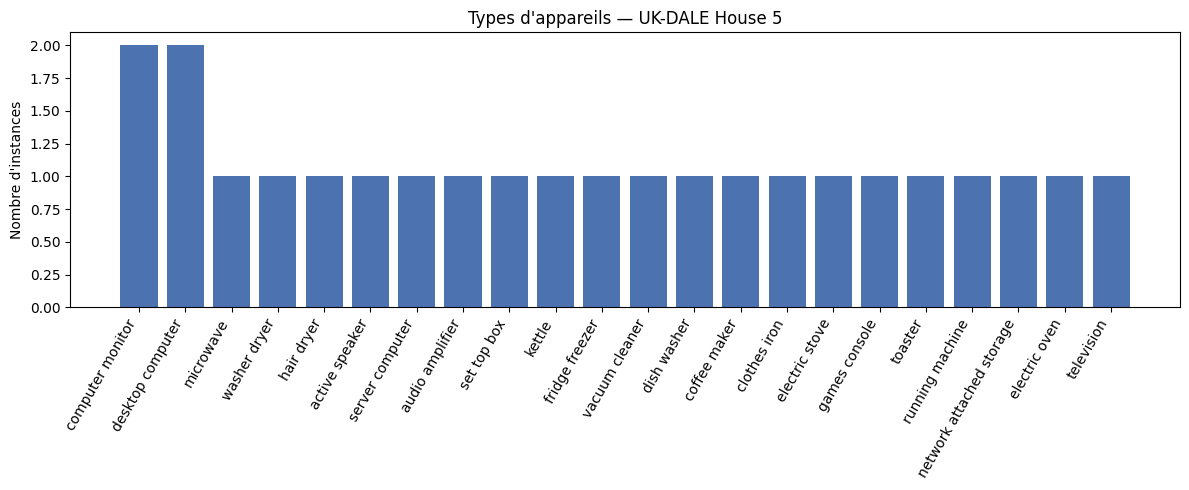

In [64]:
# ===== CELLULE 7 : plot 1 — fréquence des types d'appareils =====
items = counts.most_common()
labels = [k for k, _ in items]
vals   = [v for _, v in items]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(labels, vals, color='#4C72B0')
ax.set_ylabel("Nombre d'instances")
ax.set_title("Types d'appareils — UK-DALE House 5")
plt.xticks(rotation=60, ha='right')
plt.tight_layout(); plt.show()

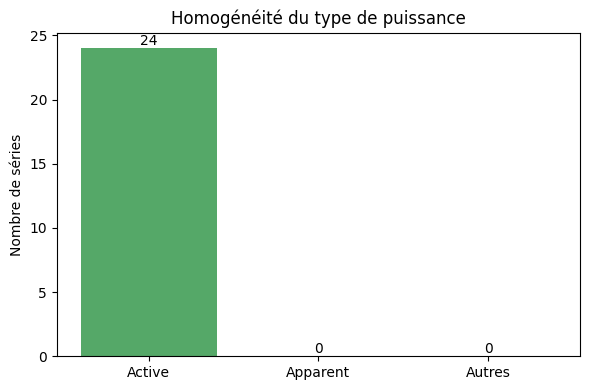

In [59]:
# ===== CELLULE 8 : plot 2 — répartition active / apparente / autres =====
groupes = ['Active', 'Apparent', 'Autres']
tailles = [len(D_active), len(D_apparent), len(autres)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(groupes, tailles, color=['#55A868', '#C44E52', '#8C8C8C'])
for i, v in enumerate(tailles):
    ax.text(i, v, str(v), ha='center', va='bottom')
ax.set_ylabel("Nombre de séries")
ax.set_title("Homogénéité du type de puissance")
plt.tight_layout(); plt.show()

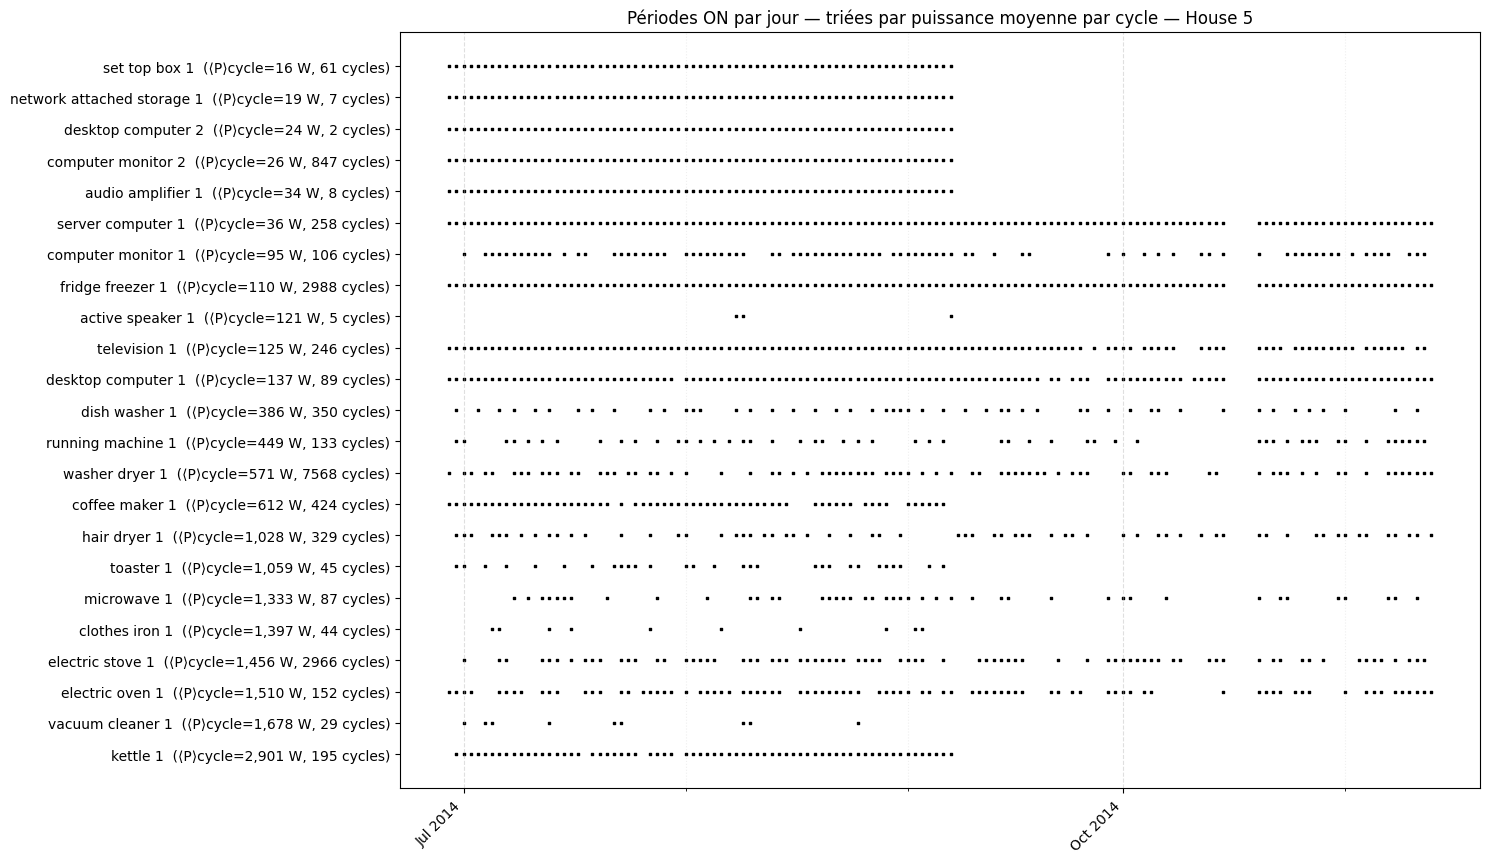

Classement par puissance moyenne par cycle (W) :
    2,900.5 W/cycle   (   195 cycles, seuil 2000 W)   kettle 1
    1,678.3 W/cycle   (    29 cycles, seuil 40 W)   vacuum cleaner 1
    1,509.6 W/cycle   (   152 cycles, seuil 50 W)   electric oven 1
    1,455.6 W/cycle   (  2966 cycles, seuil 50 W)   electric stove 1
    1,396.9 W/cycle   (    44 cycles, seuil 100 W)   clothes iron 1
    1,332.7 W/cycle   (    87 cycles, seuil 200 W)   microwave 1
    1,058.5 W/cycle   (    45 cycles, seuil 100 W)   toaster 1
    1,028.2 W/cycle   (   329 cycles, seuil 50 W)   hair dryer 1
      612.2 W/cycle   (   424 cycles, seuil 40 W)   coffee maker 1
      571.3 W/cycle   (  7568 cycles, seuil 20 W)   washer dryer 1
      449.0 W/cycle   (   133 cycles, seuil 50 W)   running machine 1
      385.7 W/cycle   (   350 cycles, seuil 10 W)   dish washer 1
      137.3 W/cycle   (    89 cycles, seuil 20 W)   desktop computer 1
      125.4 W/cycle   (   246 cycles, seuil 20 W)   television 1
      121.3 W/c

In [65]:
# ===== CELLULE 9 : timeline ON/jour + tri par PUISSANCE MOYENNE PAR CYCLE =====
import numpy as np
import matplotlib.dates as mdates

def get_seuil(key):
    return seuils_meta.get(key, SEUIL_DEFAUT)

GAP_MAX = pd.Timedelta(seconds=3 * SAMPLE_PERIOD)   # trou -> rupture de cycle

def cycles_stats(s, seuil, sample_period=SAMPLE_PERIOD, gap_max=GAP_MAX):
    """Segmente la série en cycles ON (runs consécutifs > seuil, coupés par
    un retour sous le seuil OU un trou temporel). Renvoie :
      - mean_of_cycle_means : moyenne des puissances moyennes de chaque cycle (W)
      - n_cycles, on_index (index des points ON pour le plot)."""
    s = s.dropna()
    if len(s) == 0:
        return np.nan, 0, s.index[:0]
    on_mask = (s > seuil).values
    if not on_mask.any():
        return np.nan, 0, s.index[:0]

    vals = s.values
    idx  = s.index
    # rupture si : on->off, OU trou temporel > gap_max entre deux points consécutifs
    dt = np.diff(idx.values).astype('timedelta64[ns]').astype('int64')
    gap = np.empty(len(idx), dtype=bool); gap[0] = True
    gap[1:] = dt > np.int64(gap_max.value)

    cycle_means = []
    cur_sum = 0.0; cur_cnt = 0
    for k in range(len(idx)):
        if on_mask[k]:
            # nouveau cycle si point précédent OFF ou trou temporel
            if cur_cnt > 0 and (gap[k] or not on_mask[k-1]):
                cycle_means.append(cur_sum / cur_cnt)
                cur_sum = 0.0; cur_cnt = 0
            cur_sum += vals[k]; cur_cnt += 1
        else:
            if cur_cnt > 0:
                cycle_means.append(cur_sum / cur_cnt)
                cur_sum = 0.0; cur_cnt = 0
    if cur_cnt > 0:
        cycle_means.append(cur_sum / cur_cnt)

    on_index = idx[on_mask]
    if not cycle_means:
        return np.nan, 0, on_index
    return float(np.mean(cycle_means)), len(cycle_means), on_index

# construction
entries = [(f"{k.type} {k.instance}", s, get_seuil(k)) for k, s in {**D_active, **D_apparent}.items()]
entries += [(lbl, s, get_seuil(lbl)) for lbl, s in autres.items()]

ranked = []
for name, s, seuil in entries:
    mcm, ncyc, on_index = cycles_stats(s, seuil)
    if ncyc == 0 or np.isnan(mcm):
        continue
    ranked.append((name, seuil, mcm, ncyc, on_index))

# tri par puissance moyenne PAR CYCLE décroissante -> plus "intense" à i=0 (en bas)
ranked.sort(key=lambda r: r[2], reverse=True)

fig, ax = plt.subplots(figsize=(15, max(4, 0.38 * len(ranked))))
for i, (name, seuil, mcm, ncyc, on_index) in enumerate(ranked):
    jours = pd.Series(1, index=on_index).resample('1D').size()
    jours = jours[jours > 0]
    ax.scatter(jours.index, np.full(len(jours), i), s=4, color='black', marker='s')

ax.set_yticks(range(len(ranked)))
ax.set_yticklabels([f"{name}  (⟨P⟩cycle={mcm:,.0f} W, {ncyc} cycles)"
                    for name, _, mcm, ncyc, _ in ranked])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.grid(True, axis='x', which='major', linestyle='--', alpha=0.4)
ax.grid(True, axis='x', which='minor', linestyle=':',  alpha=0.2)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title("Périodes ON par jour — triées par puissance moyenne par cycle — House 5")
plt.tight_layout(); plt.show()

print("Classement par puissance moyenne par cycle (W) :")
for name, seuil, mcm, ncyc, _ in ranked:
    print(f"  {mcm:9,.1f} W/cycle   ({ncyc:6d} cycles, seuil {seuil:g} W)   {name}")

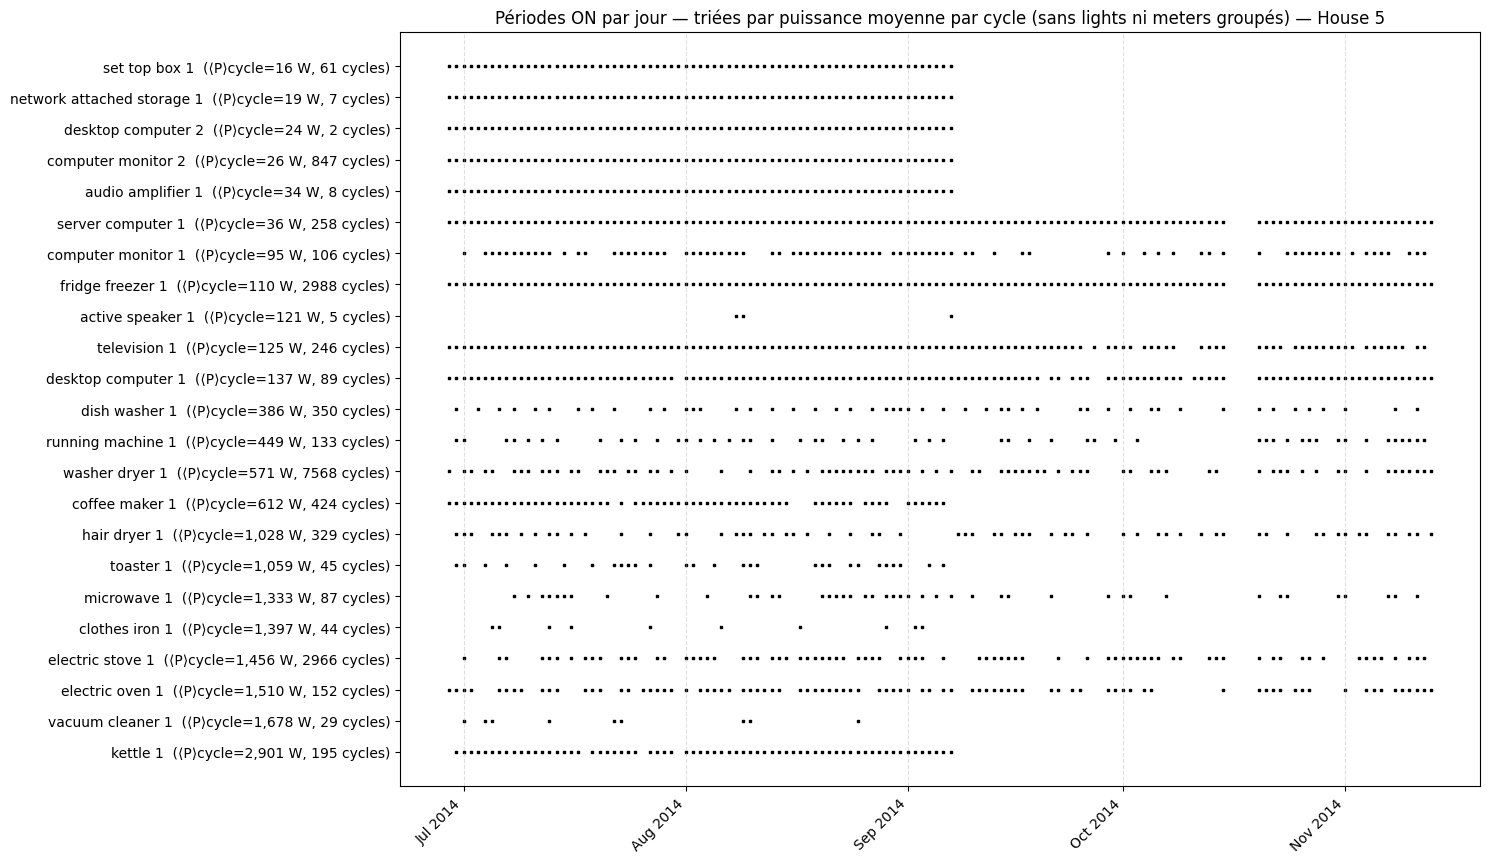

Classement par puissance moyenne par cycle (W) :
    2,900.5 W/cycle   (   195 cycles, seuil 2000 W)   kettle 1
    1,678.3 W/cycle   (    29 cycles, seuil 40 W)   vacuum cleaner 1
    1,509.6 W/cycle   (   152 cycles, seuil 50 W)   electric oven 1
    1,455.6 W/cycle   (  2966 cycles, seuil 50 W)   electric stove 1
    1,396.9 W/cycle   (    44 cycles, seuil 100 W)   clothes iron 1
    1,332.7 W/cycle   (    87 cycles, seuil 200 W)   microwave 1
    1,058.5 W/cycle   (    45 cycles, seuil 100 W)   toaster 1
    1,028.2 W/cycle   (   329 cycles, seuil 50 W)   hair dryer 1
      612.2 W/cycle   (   424 cycles, seuil 40 W)   coffee maker 1
      571.3 W/cycle   (  7568 cycles, seuil 20 W)   washer dryer 1
      449.0 W/cycle   (   133 cycles, seuil 50 W)   running machine 1
      385.7 W/cycle   (   350 cycles, seuil 10 W)   dish washer 1
      137.3 W/cycle   (    89 cycles, seuil 20 W)   desktop computer 1
      125.4 W/cycle   (   246 cycles, seuil 20 W)   television 1
      121.3 W/c

In [66]:
# ===== CELLULE 10 : timeline ON/jour + tri par PUISSANCE MOYENNE PAR CYCLE =====
# Filtres : on exclut les groupes 'autres_meter_*' et tous les 'light *'.
import numpy as np
import matplotlib.dates as mdates

def get_seuil(key):
    return seuils_meta.get(key, SEUIL_DEFAUT)

GAP_MAX = pd.Timedelta(seconds=3 * SAMPLE_PERIOD)   # trou -> rupture de cycle

def cycles_stats(s, seuil, sample_period=SAMPLE_PERIOD, gap_max=GAP_MAX):
    """Segmente la série en cycles ON (runs consécutifs > seuil, coupés par
    un retour sous le seuil OU un trou temporel). Renvoie :
      - mean_of_cycle_means : moyenne des puissances moyennes de chaque cycle (W)
      - n_cycles, on_index (index des points ON pour le plot)."""
    s = s.dropna()
    if len(s) == 0:
        return np.nan, 0, s.index[:0]
    on_mask = (s > seuil).values
    if not on_mask.any():
        return np.nan, 0, s.index[:0]
    vals = s.values
    idx  = s.index
    # rupture si : on->off, OU trou temporel > gap_max entre deux points consécutifs
    dt = np.diff(idx.values).astype('timedelta64[ns]').astype('int64')
    gap = np.empty(len(idx), dtype=bool); gap[0] = True
    gap[1:] = dt > np.int64(gap_max.value)
    cycle_means = []
    cur_sum = 0.0; cur_cnt = 0
    for k in range(len(idx)):
        if on_mask[k]:
            # nouveau cycle si point précédent OFF ou trou temporel
            if cur_cnt > 0 and (gap[k] or not on_mask[k-1]):
                cycle_means.append(cur_sum / cur_cnt)
                cur_sum = 0.0; cur_cnt = 0
            cur_sum += vals[k]; cur_cnt += 1
        else:
            if cur_cnt > 0:
                cycle_means.append(cur_sum / cur_cnt)
                cur_sum = 0.0; cur_cnt = 0
    if cur_cnt > 0:
        cycle_means.append(cur_sum / cur_cnt)
    on_index = idx[on_mask]
    if not cycle_means:
        return np.nan, 0, on_index
    return float(np.mean(cycle_means)), len(cycle_means), on_index

# --- construction + filtres : exclut 'autres_meter_*' et tous les 'light ' ---
def garder(name):
    return not (name.startswith('autres_meter') or name.startswith('light '))

entries = [(f"{k.type} {k.instance}", s, get_seuil(k))
           for k, s in {**D_active, **D_apparent}.items()
           if garder(f"{k.type} {k.instance}")]
entries += [(lbl, s, get_seuil(lbl))
            for lbl, s in autres.items()
            if garder(lbl)]

ranked = []
for name, s, seuil in entries:
    mcm, ncyc, on_index = cycles_stats(s, seuil)
    if ncyc == 0 or np.isnan(mcm):
        continue
    ranked.append((name, seuil, mcm, ncyc, on_index))

# tri par puissance moyenne PAR CYCLE décroissante -> plus "intense" à i=0 (en bas)
ranked.sort(key=lambda r: r[2], reverse=True)

fig, ax = plt.subplots(figsize=(15, max(4, 0.38 * len(ranked))))
for i, (name, seuil, mcm, ncyc, on_index) in enumerate(ranked):
    jours = pd.Series(1, index=on_index).resample('1D').size()
    jours = jours[jours > 0]
    ax.scatter(jours.index, np.full(len(jours), i), s=4, color='black', marker='s')

ax.set_yticks(range(len(ranked)))
ax.set_yticklabels([f"{name}  (⟨P⟩cycle={mcm:,.0f} W, {ncyc} cycles)"
                    for name, _, mcm, ncyc, _ in ranked])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.grid(True, axis='x', which='major', linestyle='--', alpha=0.4)
ax.grid(True, axis='x', which='minor', linestyle=':',  alpha=0.2)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title("Périodes ON par jour — triées par puissance moyenne par cycle "
             "(sans lights ni meters groupés) — House 5")
plt.tight_layout(); plt.show()

print("Classement par puissance moyenne par cycle (W) :")
for name, seuil, mcm, ncyc, _ in ranked:
    print(f"  {mcm:9,.1f} W/cycle   ({ncyc:6d} cycles, seuil {seuil:g} W)   {name}")

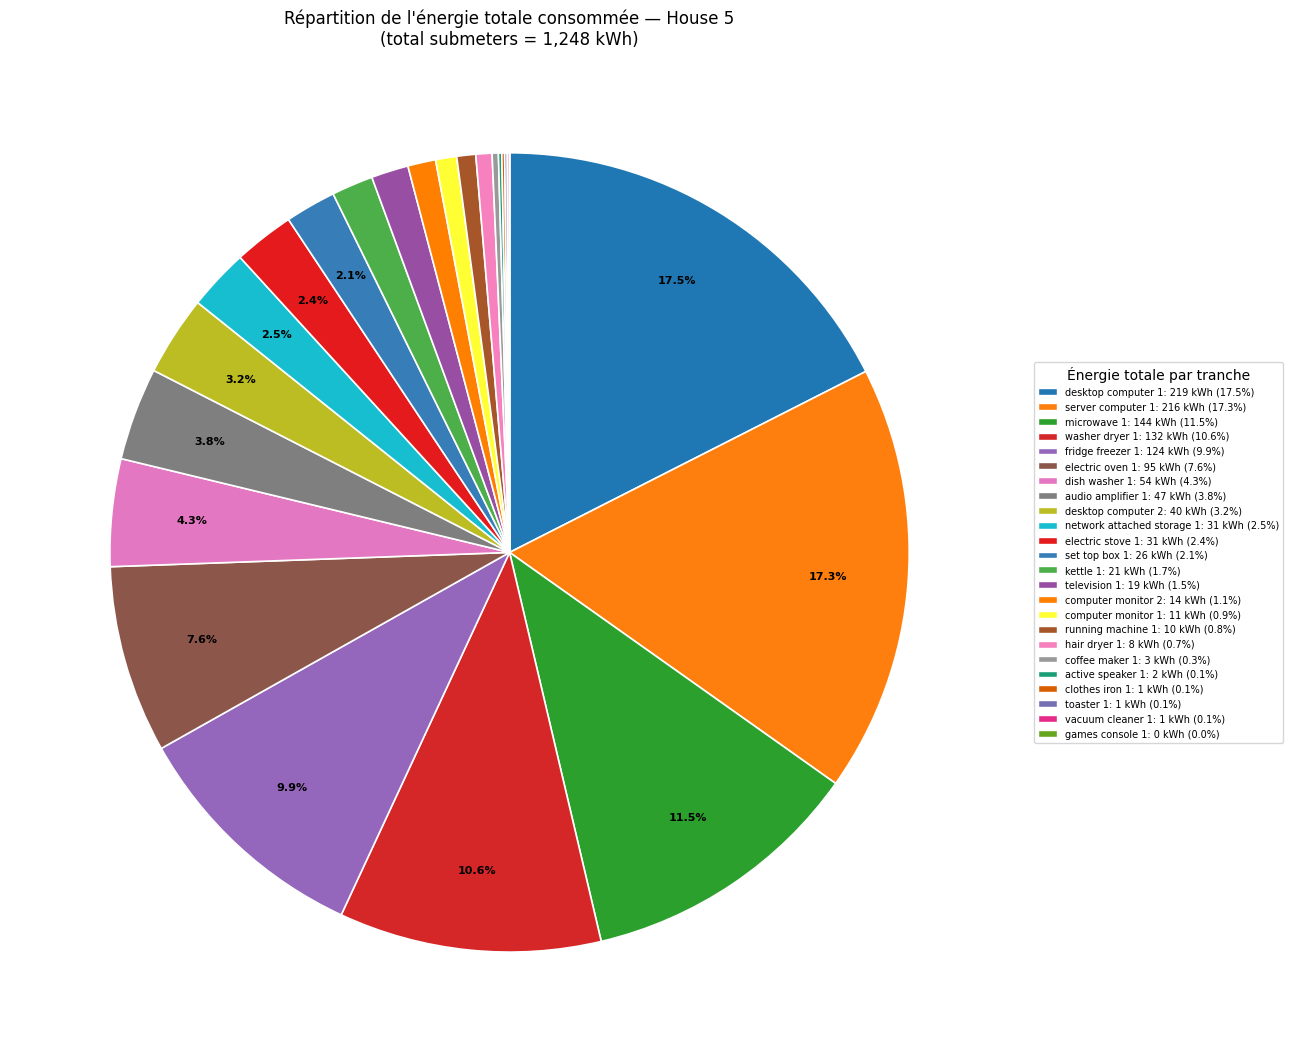

TOTAL submeters : 1,247.6 kWh

   17.5%        218.6 kWh   desktop computer 1
   17.3%        215.7 kWh   server computer 1
   11.5%        143.6 kWh   microwave 1
   10.6%        132.3 kWh   washer dryer 1
    9.9%        123.8 kWh   fridge freezer 1
    7.6%         94.7 kWh   electric oven 1
    4.3%         54.2 kWh   dish washer 1
    3.8%         46.8 kWh   audio amplifier 1
    3.2%         40.3 kWh   desktop computer 2
    2.5%         30.8 kWh   network attached storage 1
    2.4%         30.5 kWh   electric stove 1
    2.1%         25.6 kWh   set top box 1
    1.7%         21.0 kWh   kettle 1
    1.5%         18.8 kWh   television 1
    1.1%         14.1 kWh   computer monitor 2
    0.9%         10.6 kWh   computer monitor 1
    0.8%          9.5 kWh   running machine 1
    0.7%          8.1 kWh   hair dryer 1
    0.3%          3.2 kWh   coffee maker 1
    0.1%          1.7 kWh   active speaker 1
    0.1%          1.4 kWh   clothes iron 1
    0.1%          1.3 kWh   toaster 1

In [67]:
# ===== CELLULE 11 : pie chart énergie totale — couleurs contrastées + hachures =====
import numpy as np
import matplotlib.pyplot as plt

def energie_kwh(s):
    s = s.dropna()
    return float(s.sum()) * SAMPLE_PERIOD / 3600 / 1000 if len(s) else 0.0

# 1) énergie + nature
energ, kind_of = {}, {}
for k, s in {**D_active, **D_apparent}.items():
    name = f"{k.type} {k.instance}"
    energ[name] = energie_kwh(s)
    kind_of[name] = 'lights' if k.type == 'light' else 'indiv'
for lbl, s in autres.items():
    energ[lbl] = energie_kwh(s)
    kind_of[lbl] = 'autres'

lights   = {n: e for n, e in energ.items() if kind_of[n] == 'lights'}
autres_e = {n: e for n, e in energ.items() if kind_of[n] == 'autres'}
indiv    = {n: e for n, e in energ.items() if kind_of[n] == 'indiv'}

# 2) tranches majeures triées décroissant
major = [(n, e, 'indiv') for n, e in indiv.items()]
if lights:
    major.append((f"Lights ({len(lights)})", sum(lights.values()), 'lights'))
if autres_e:
    major.append((f"Autres meters ({len(autres_e)})", sum(autres_e.values()), 'autres'))
major.sort(key=lambda t: t[1], reverse=True)

total  = sum(e for _, e, _ in major)
labels = [m[0] for m in major]
sizes  = [m[1] for m in major]

# 3) styles : couleurs contrastées (tab10+Set1+Dark2) x hachures -> chaque tranche unique
base_colors = (list(plt.cm.tab10.colors) + list(plt.cm.Set1.colors)
               + list(plt.cm.Dark2.colors))
hatches_cycle = ['', '///', '...', 'xxx', '\\\\\\', '+++', 'ooo', '**', '||', '--']

n = len(major)
colors  = [base_colors[i % len(base_colors)] for i in range(n)]
# change de hachure à chaque fois qu'on reboucle sur les couleurs
hatches = [hatches_cycle[(i // len(base_colors)) % len(hatches_cycle)] for i in range(n)]
# les deux agrégats reçoivent un style réservé bien identifiable
for i, (lab, e, knd) in enumerate(major):
    if knd == 'lights':
        colors[i] = (1.0, 0.85, 0.0); hatches[i] = '....'   # jaune pointillé
    elif knd == 'autres':
        colors[i] = (0.55, 0.55, 0.55); hatches[i] = 'xxxx' # gris croisé

def fmt(p):
    return f'{p:.1f}%' if p >= 2.0 else ''

fig, ax = plt.subplots(figsize=(13, 13))
wedges, _, autotexts = ax.pie(
    sizes, colors=colors, autopct=fmt, pctdistance=0.80,
    startangle=90, counterclock=False,
    wedgeprops=dict(edgecolor='white', linewidth=1.2),
    textprops=dict(fontsize=8, weight='bold'))
for w, h in zip(wedges, hatches):
    w.set_hatch(h)
for t in autotexts:
    t.set_color('black')
ax.set_aspect('equal')

# 4) subdivision interne des deux agrégats (rayons pointillés)
def subdivise(wedge, subitems, total_all):
    subitems = sorted(subitems.items(), key=lambda t: t[1], reverse=True)
    ssum = sum(e for _, e in subitems)
    if ssum <= 0:
        return
    t1, t2 = wedge.theta1, wedge.theta2
    cx, cy = wedge.center
    r = wedge.r
    cum = 0.0
    for j, (nm, e) in enumerate(subitems):
        frac = e / ssum
        mid = np.deg2rad(t1 + (cum + frac / 2) * (t2 - t1))
        rl = 0.66 * r
        short = nm.replace('autres_meter_', 'm').replace('light ', 'L')
        ax.text(cx + rl*np.cos(mid), cy + rl*np.sin(mid),
                f"{short}\n{100*e/total_all:.1f}%",
                ha='center', va='center', fontsize=6)
        cum += frac
        if j < len(subitems) - 1:
            b = np.deg2rad(t1 + cum * (t2 - t1))
            ax.plot([cx, cx + r*np.cos(b)], [cy, cy + r*np.sin(b)],
                    linestyle=':', color='black', linewidth=0.9)

for w, (lab, e, knd) in zip(wedges, major):
    if knd == 'lights':
        subdivise(w, lights, total)
    elif knd == 'autres':
        subdivise(w, autres_e, total)

# 5) légende avec patches assortis (couleur + hachure)
import matplotlib.patches as mpatches
handles = [mpatches.Patch(facecolor=colors[i], hatch=hatches[i],
                          edgecolor='white',
                          label=f"{labels[i]}: {sizes[i]:,.0f} kWh "
                                f"({100*sizes[i]/total:.1f}%)")
           for i in range(n)]
ax.legend(handles=handles, title="Énergie totale par tranche",
          loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7)

ax.set_title(f"Répartition de l'énergie totale consommée — House 5\n"
             f"(total submeters = {total:,.0f} kWh)", fontsize=12)
plt.tight_layout(); plt.show()

# récap
print(f"TOTAL submeters : {total:,.1f} kWh\n")
for lab, e, _ in major:
    print(f"  {100*e/total:5.1f}%   {e:10,.1f} kWh   {lab}")
print("\nDétail Lights :")
for nm, e in sorted(lights.items(), key=lambda t: t[1], reverse=True):
    print(f"  {100*e/total:5.1f}%   {e:10,.1f} kWh   {nm}")
print("\nDétail Autres meters :")
for nm, e in sorted(autres_e.items(), key=lambda t: t[1], reverse=True):
    print(f"  {100*e/total:5.1f}%   {e:10,.1f} kWh   {nm}")